In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
payments = pd.read_csv("payments.csv")
products = pd.read_csv("products.csv")

In [22]:
print(orders.columns.tolist())
print(customers.columns.tolist())

['OrderID', 'CustomerID', 'OrderDate', 'ProductID', 'Quantity', 'Discount', 'PaymentMethod', 'Status']
['CustomerID', 'Age', 'City', 'SignupDate', 'CustomerSegment']


In [24]:
df = orders.merge(customers, on="CustomerID", how="left")
df = df.merge(payments, on="OrderID", how="left")
df = df.merge(products, on="ProductID", how="left")

In [25]:
df.head()

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,PaymentID,PaymentDate,PaymentStatus,ProductName,Category,UnitPrice
0,500001,103695,2025-08-28,2003,4.0,0.1,Gateway,Completed,36.0,Qom,2024-03-05,Regular,800001,2025-08-28,Paid,USB-C Cable,Accessories,9.0
1,500002,107935,2024-05-31,2014,1.0,0.1,Wallet,Completed,49.0,Kerman,2025-06-04,Regular,800002,2024-05-31,Paid,Backpack,Accessories,42.0
2,500003,105141,2025-08-10,2002,1.0,0.2,CardToCard,Completed,36.0,Tehran,2025-10-19,Regular,800003,2025-08-10,Paid,Mechanical Keyboard,Electronics,62.0
3,500004,108780,2024-10-11,2012,1.0,0.1,Gateway,Completed,45.0,Shiraz,2023-12-07,Regular,800004,2024-10-11,Paid,Office Chair,Home Office,180.0
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,24.0,Karaj,2023-12-02,Regular,800005,2024-02-19,Paid,Phone Case,Accessories,14.0


In [26]:
df.to_csv("combined_data.csv", index=False)

In [28]:
print(df.columns.tolist())

['OrderID', 'CustomerID', 'OrderDate', 'ProductID', 'Quantity', 'Discount', 'PaymentMethod', 'Status', 'Age', 'City', 'SignupDate', 'CustomerSegment', 'PaymentID', 'PaymentDate', 'PaymentStatus', 'ProductName', 'Category', 'UnitPrice']


In [29]:
print(df.head())

   OrderID  CustomerID   OrderDate  ProductID  Quantity  Discount  \
0   500001      103695  2025-08-28       2003       4.0       0.1   
1   500002      107935  2024-05-31       2014       1.0       0.1   
2   500003      105141  2025-08-10       2002       1.0       0.2   
3   500004      108780  2024-10-11       2012       1.0       0.1   
4   500005      101187  2024-02-19       2008       2.0       0.0   

  PaymentMethod     Status   Age    City  SignupDate CustomerSegment  \
0       Gateway  Completed  36.0     Qom  2024-03-05         Regular   
1        Wallet  Completed  49.0  Kerman  2025-06-04         Regular   
2    CardToCard  Completed  36.0  Tehran  2025-10-19         Regular   
3       Gateway  Completed  45.0  Shiraz  2023-12-07         Regular   
4       Gateway  Completed  24.0   Karaj  2023-12-02         Regular   

   PaymentID PaymentDate PaymentStatus          ProductName     Category  \
0     800001  2025-08-28          Paid          USB-C Cable  Accessories   


In [31]:
print(df.columns.tolist())

['OrderID', 'CustomerID', 'OrderDate', 'ProductID', 'Quantity', 'Discount', 'PaymentMethod', 'Status', 'Age', 'City', 'SignupDate', 'CustomerSegment', 'PaymentID', 'PaymentDate', 'PaymentStatus', 'ProductName', 'Category', 'UnitPrice']


In [32]:
df["Sales"] = df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"])

In [33]:
print(df["Discount"].head())

0    0.1
1    0.1
2    0.2
3    0.1
4    0.0
Name: Discount, dtype: float64


In [34]:
df["Sales"] = df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"] / 100)

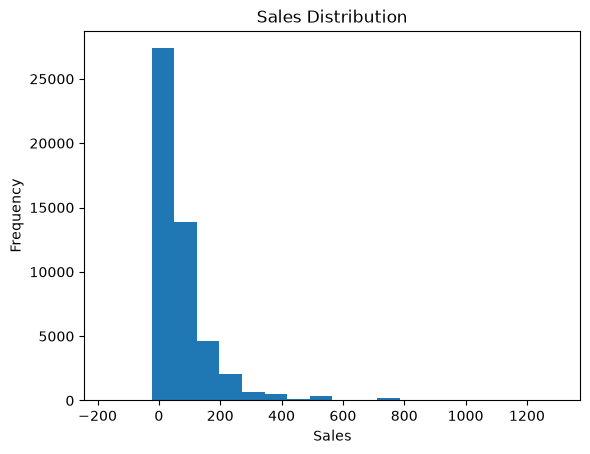

In [35]:
plt.hist(df["Sales"], bins=20)

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")

plt.show()

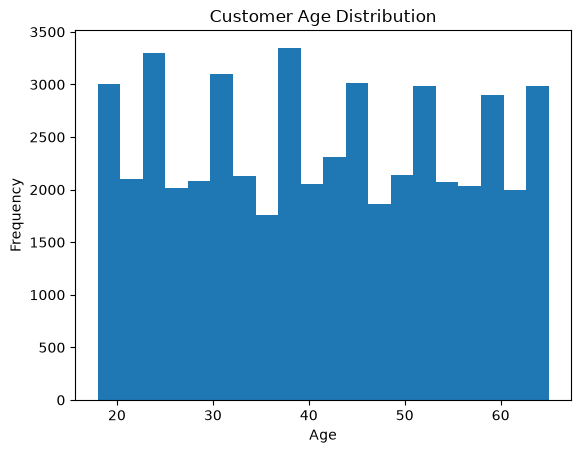

In [36]:
plt.hist(df["Age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Customer Age Distribution")

plt.show()


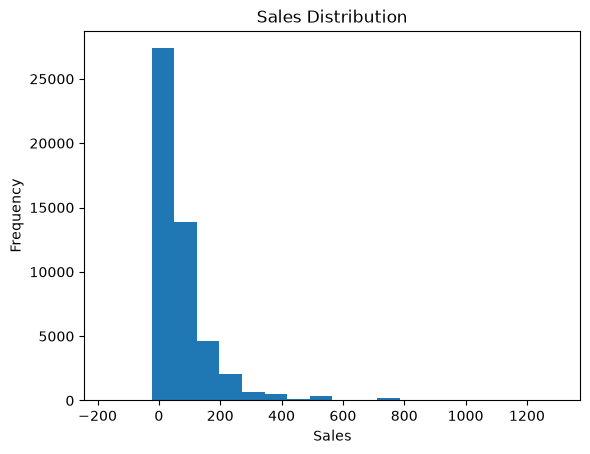

In [37]:
plt.hist(df["Sales"], bins=20)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.show()


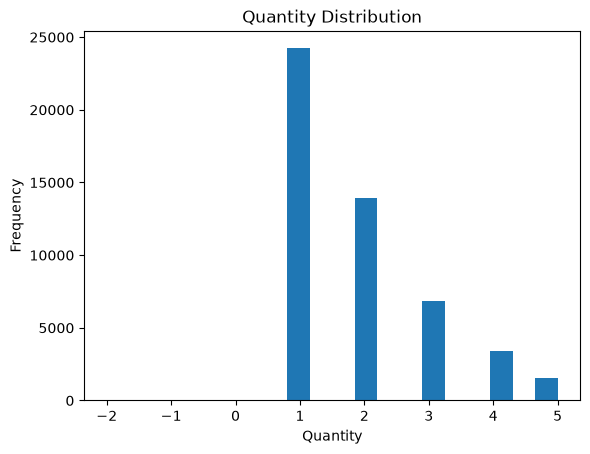

In [38]:
# Q3
plt.hist(df["Quantity"], bins=20)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Quantity Distribution")
plt.show()

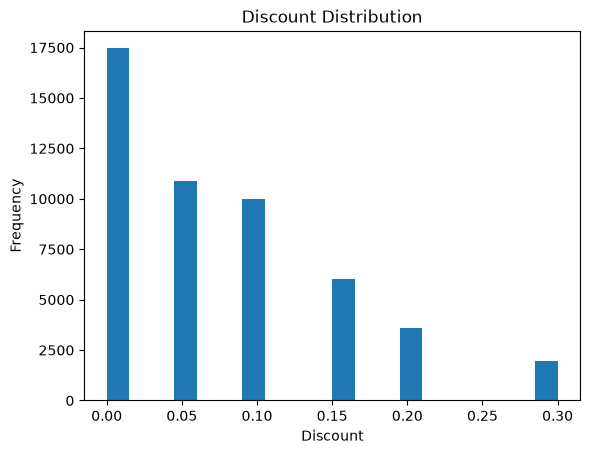

In [39]:
# Q4
plt.hist(df["Discount"], bins=20)
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.title("Discount Distribution")
plt.show()

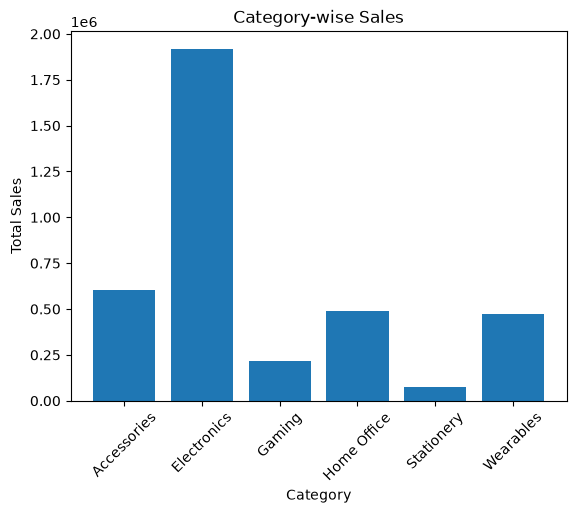

In [40]:
# Q5
data = df.groupby("Category")["Sales"].sum()

plt.bar(data.index, data.values)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Category-wise Sales")
plt.xticks(rotation=45)
plt.show()

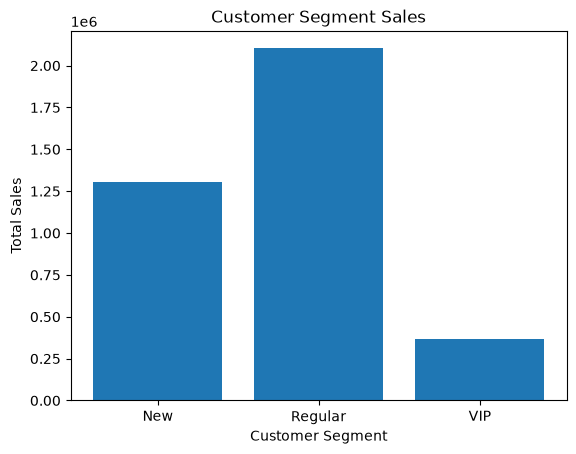

In [41]:
# Q6
data = df.groupby("CustomerSegment")["Sales"].sum()

plt.bar(data.index, data.values)
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.title("Customer Segment Sales")
plt.show()

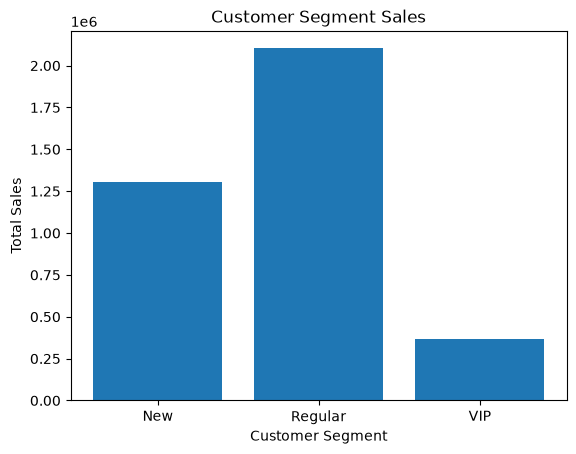

In [42]:
# Q6
data = df.groupby("CustomerSegment")["Sales"].sum()

plt.bar(data.index, data.values)
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.title("Customer Segment Sales")
plt.show()

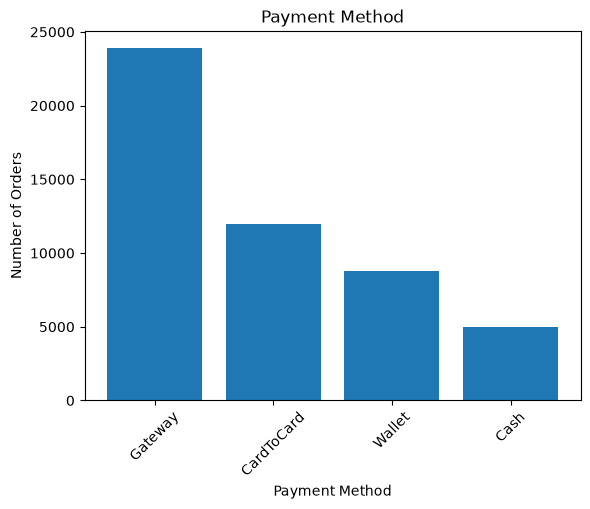

In [43]:
# Q7
data = df["PaymentMethod"].value_counts()

plt.bar(data.index, data.values)
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.title("Payment Method")
plt.xticks(rotation=45)
plt.show()

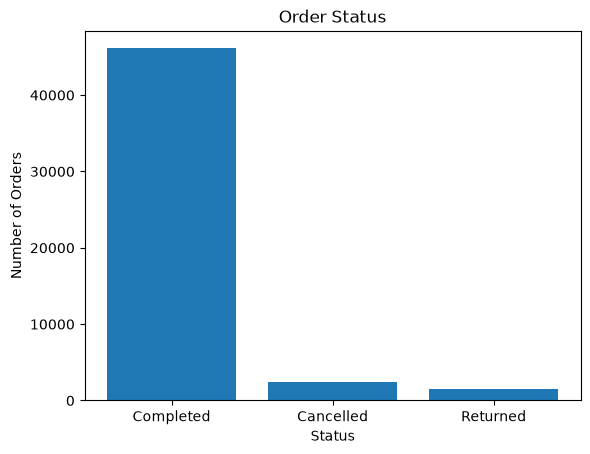

In [44]:
# Q8
data = df["Status"].value_counts()

plt.bar(data.index, data.values)
plt.xlabel("Status")
plt.ylabel("Number of Orders")
plt.title("Order Status")
plt.show()

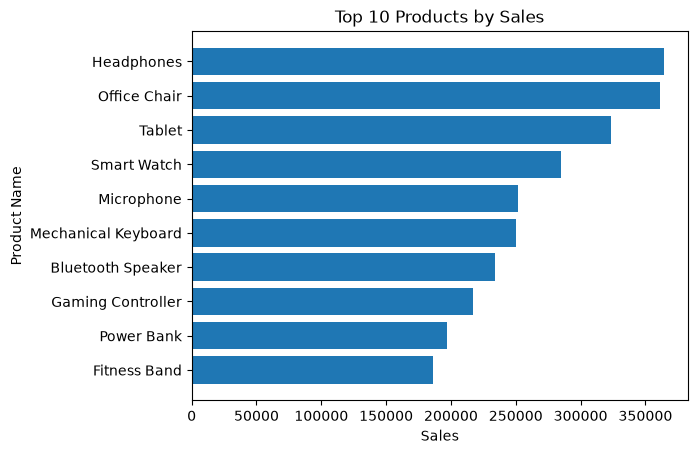

In [45]:
# Q9
data = df.groupby("ProductName")["Sales"].sum().nlargest(10)
data = data.sort_values()

plt.barh(data.index, data.values)
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.title("Top 10 Products by Sales")
plt.show()

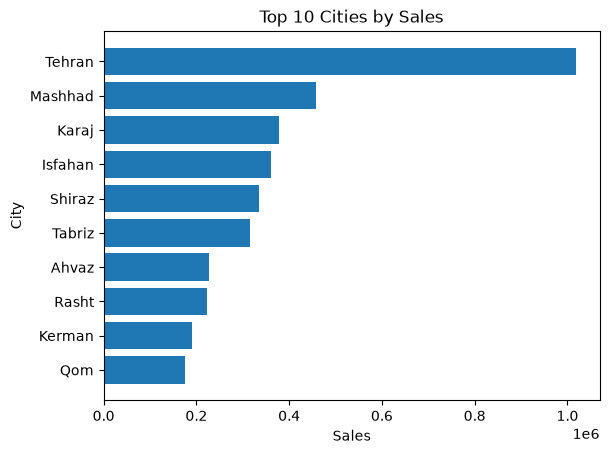

In [46]:
# Q10
data = df.groupby("City")["Sales"].sum().nlargest(10)
data = data.sort_values()

plt.barh(data.index, data.values)
plt.xlabel("Sales")
plt.ylabel("City")
plt.title("Top 10 Cities by Sales")
plt.show()

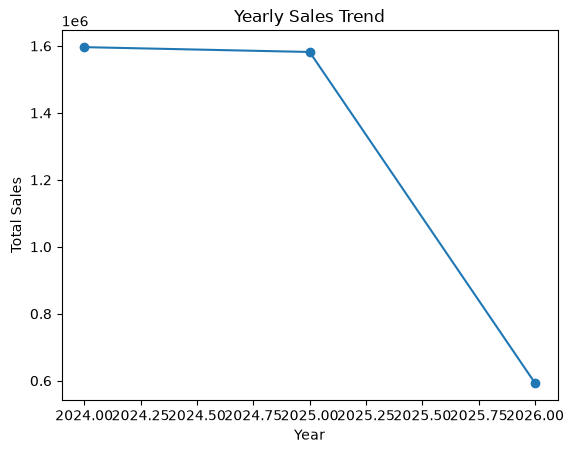

In [48]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

data = df.groupby(df["OrderDate"].dt.year)["Sales"].sum()

plt.plot(data.index, data.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Yearly Sales Trend")
plt.show()

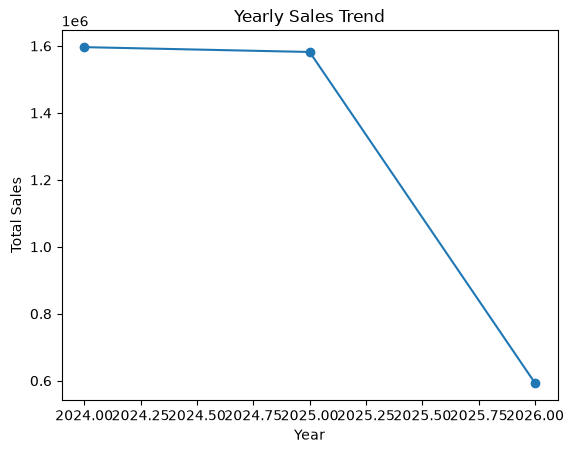

In [49]:
df["OrderDate"] = pd.to_datetime(
    df["OrderDate"],
    format="mixed",
    errors="coerce"
)

data = df.groupby(df["OrderDate"].dt.year)["Sales"].sum()

plt.plot(data.index, data.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Yearly Sales Trend")
plt.show()

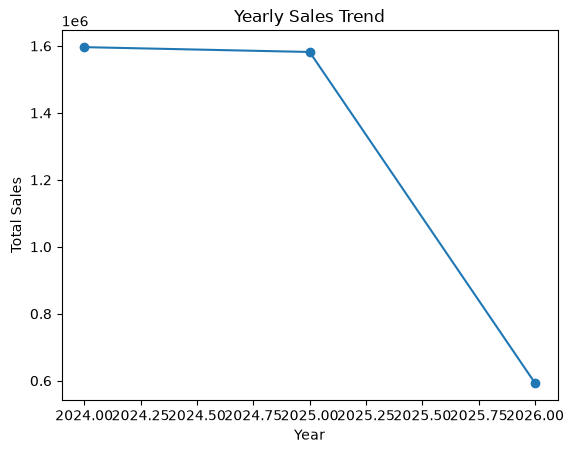

In [50]:
df["OrderDate"] = pd.to_datetime(
    df["OrderDate"],
    format="mixed",
    errors="coerce"
)

data = df.groupby(df["OrderDate"].dt.year)["Sales"].sum()

plt.plot(data.index, data.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Yearly Sales Trend")
plt.show()

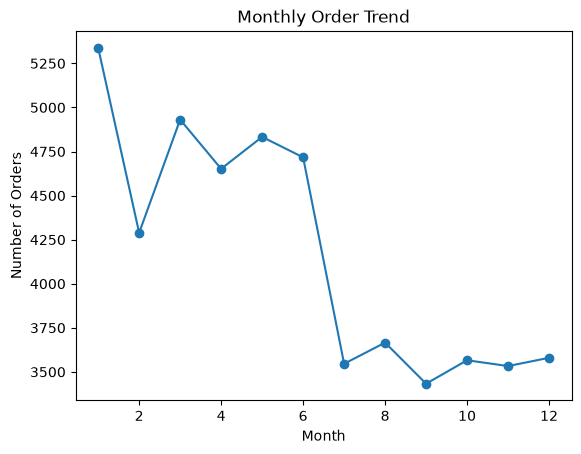

In [51]:
data = df.groupby(df["OrderDate"].dt.month).size()

plt.plot(data.index, data.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Order Trend")
plt.show()


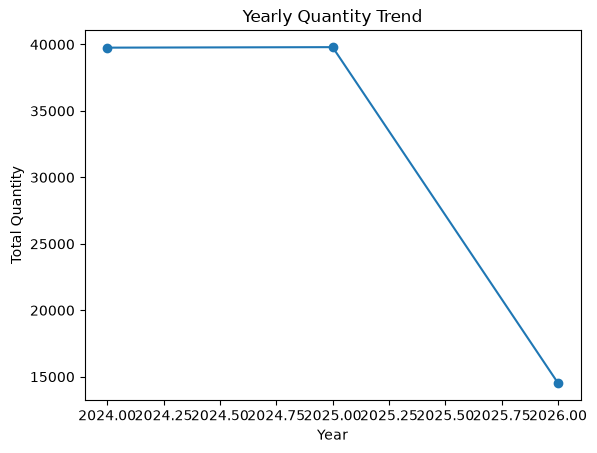

In [52]:
data = df.groupby(df["OrderDate"].dt.year)["Quantity"].sum()

plt.plot(data.index, data.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Total Quantity")
plt.title("Yearly Quantity Trend")
plt.show()

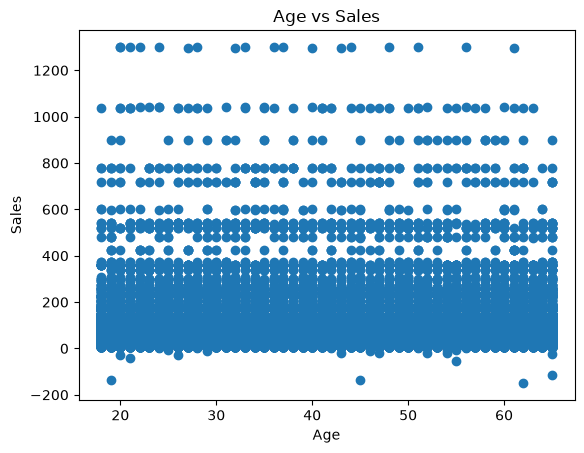

In [53]:
plt.scatter(df["Age"], df["Sales"])

plt.xlabel("Age")
plt.ylabel("Sales")
plt.title("Age vs Sales")
plt.show()

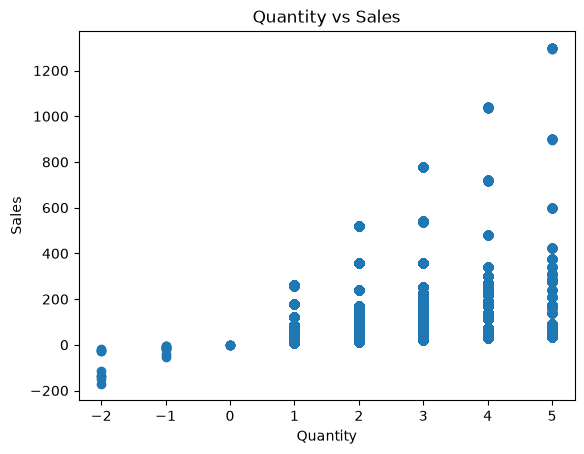

In [54]:
plt.scatter(df["Quantity"], df["Sales"])

plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()

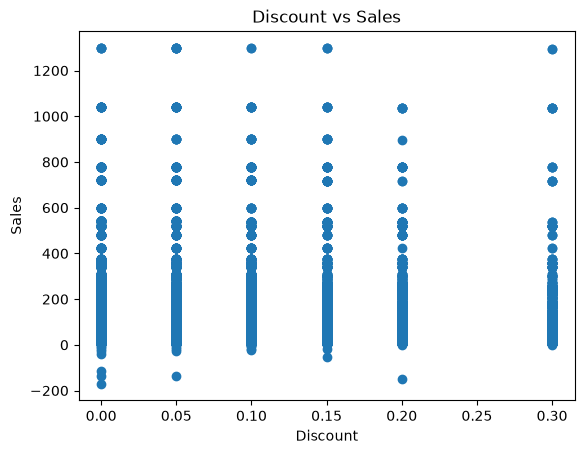

In [55]:
plt.scatter(df["Discount"], df["Sales"])

plt.xlabel("Discount")
plt.ylabel("Sales")
plt.title("Discount vs Sales")
plt.show()

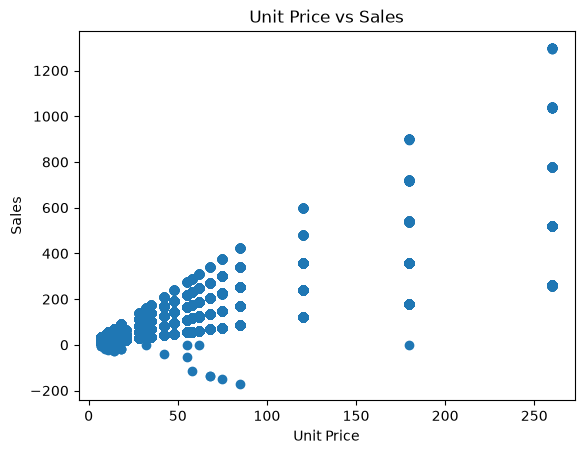

In [56]:
plt.scatter(df["UnitPrice"], df["Sales"])

plt.xlabel("Unit Price")
plt.ylabel("Sales")
plt.title("Unit Price vs Sales")
plt.show()

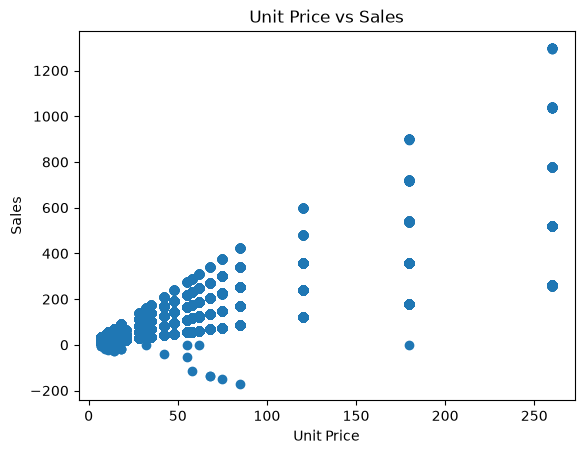

In [57]:
plt.scatter(df["UnitPrice"], df["Sales"])

plt.xlabel("Unit Price")
plt.ylabel("Sales")
plt.title("Unit Price vs Sales")
plt.show()

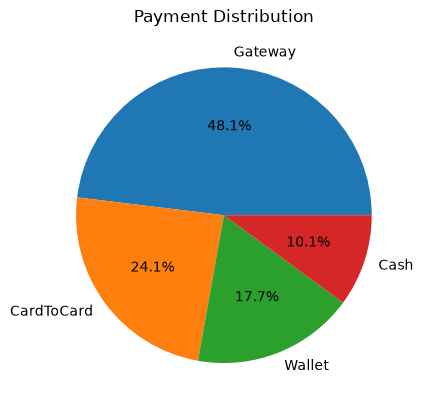

In [58]:
data = df["PaymentMethod"].value_counts()

plt.pie(data.values, labels=data.index, autopct="%1.1f%%")
plt.title("Payment Distribution")
plt.show()

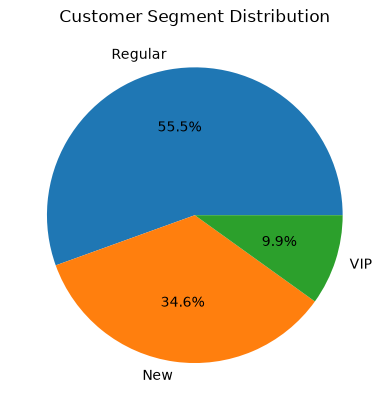

In [59]:
data = df["CustomerSegment"].value_counts()

plt.pie(data.values, labels=data.index, autopct="%1.1f%%")
plt.title("Customer Segment Distribution")
plt.show()

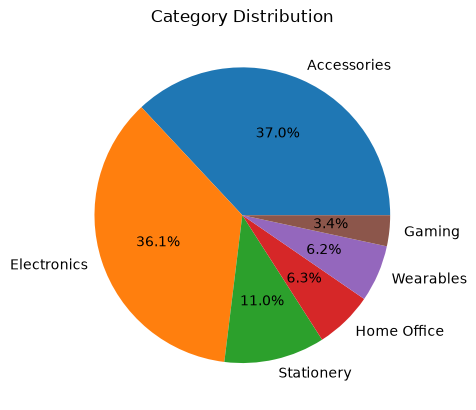

In [60]:
data = df["Category"].value_counts()

plt.pie(data.values, labels=data.index, autopct="%1.1f%%")
plt.title("Category Distribution")
plt.show()